# Benchmark

## 1. Environment

In [1]:
import cafe
import scanpy as sc
import pandas as pd

cafe.settings.backend = "cfe_docker"
# cafe.settings.backend = "conda"
# cafe.logger.setLevel("DEBUG")
cafe.logger.setLevel("INFO")

[09/17/2025 12:53:17] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

## 2. Data

In [2]:
fadata = cafe.data.read_pancrease()

# fadata = cafe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
# fadata.add_prior_information(start_cell="cell_000") # add prior information mannually
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

<Axes: title={'center': 'trajectory_pseudotime'}, xlabel='X_umap1', ylabel='X_umap2'>

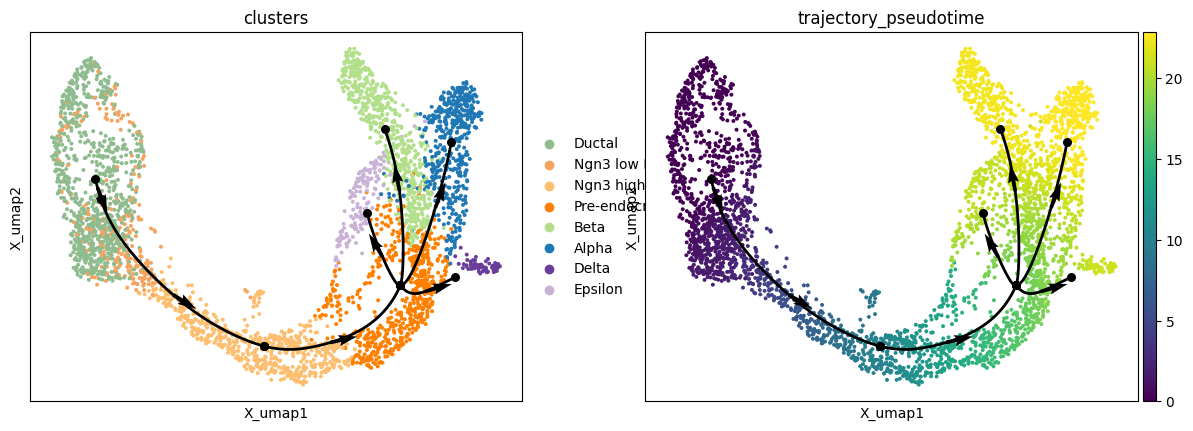

In [3]:
pseudotime_key = "trajectory_pseudotime"
fadata.obs[pseudotime_key] = fadata.get_trajectory_pseudotime()

cluster_key = "clusters"
cafe.plot.plot_trajectory(fadata, color=[cluster_key, pseudotime_key])

## 3. Method

In [4]:
# 查看可用的method

[09/17/2025 12:53:22] INFO     method backend loaded: CFE Docker Backend: comp1 in docker image 'huangzhaoyang/comp1:0.0.1'                                                                             
[09/17/2025 12:53:24] INFO     method infer trajectory successfully: CFE Docker Backend: comp1 in docker image 'huangzhaoyang/comp1:0.0.1'                                                              
[09/17/2025 12:53:28] INFO     method backend loaded: CFE Docker Backend: cytotrace2 in docker image 'huangzhaoyang/cytotrace2:0.0.1'                                                                   
[09/17/2025 12:55:19] INFO     method infer trajectory successfully: CFE Docker Backend: cytotrace2 in docker image 'huangzhaoyang/cytotrace2:0.0.1'                                                    
[09/17/2025 12:55:23] INFO     method backend loaded: CFE Docker Backend: sctc in docker image 'huangzhaoyang/sctc:0.0.1'                                                                           

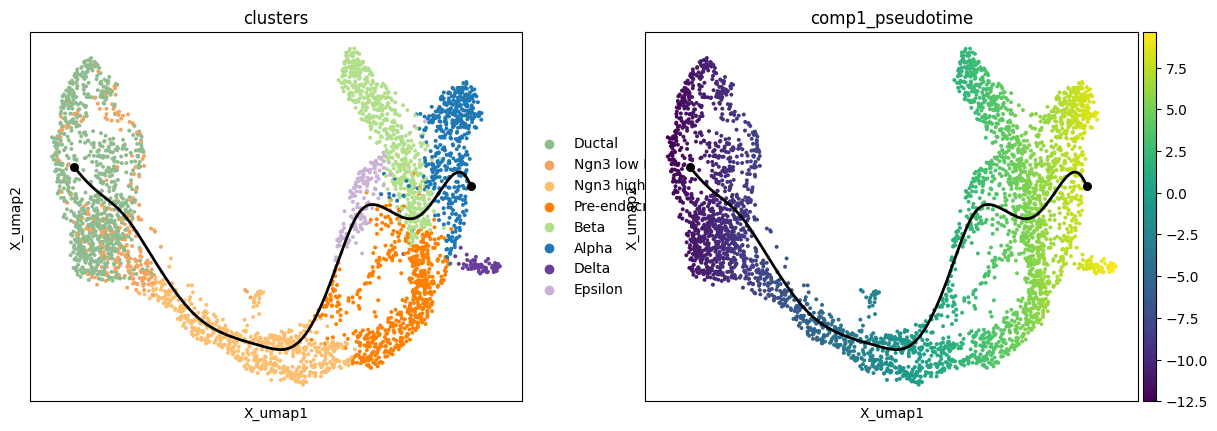

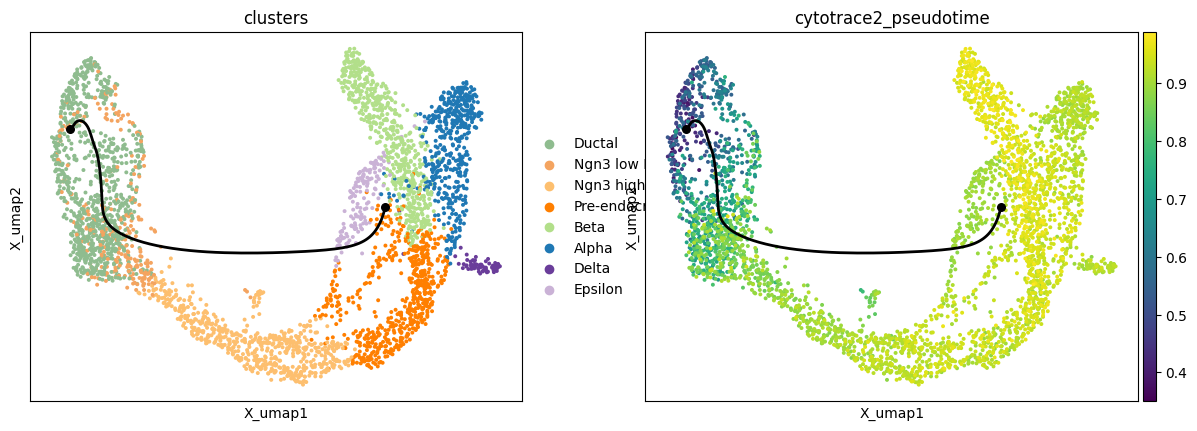

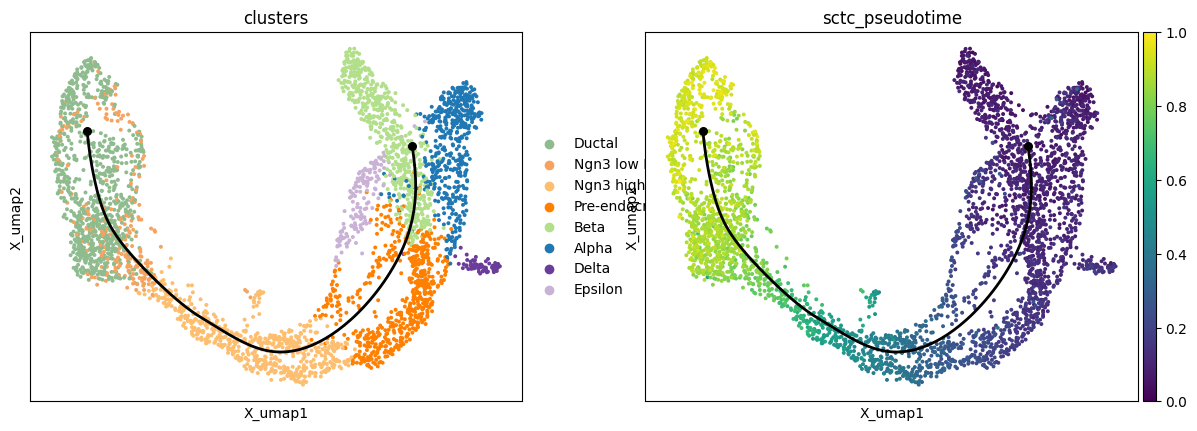

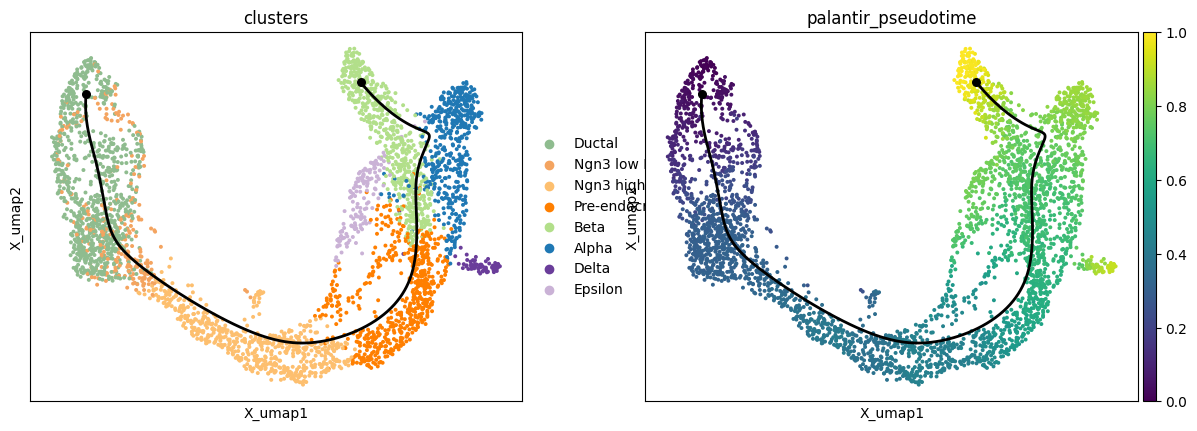

In [5]:
# cluster_key = "clusters"
# cluster_key_list = ["milestone", cluster_key]

method2parameters = {
    # new method 
    "comp1": {},
    "cytotrace2":{"cytotrace2_kwargs": {"max_cores": 8}},
    "sctc": {},
    "palantir": {}
    
    # # old dynverse method
    # "ti_comp1": {},
    # "ti_scorpius":{},
    # "ti_embeddr":{},
    # "ti_matcher":{},
    # "ti_tscan":{},
}

for method_name, parameters in method2parameters.items():
    parameters["benchmark_resource"] = True  # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    # cafe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key)
    
    # extract pseudotime and plot
    raw_wrapper_dict = fadata.get_raw_wrapper_dict()
    pseudotime_key = f"{method_name}_pseudotime"
    color_list = [cluster_key, pseudotime_key]
    if not raw_wrapper_dict == {}:
        # raw_wrapper_dict is available for conda or CFE docker
        fadata.obs[pseudotime_key] = raw_wrapper_dict["pseudotime"]
    else:
        # raw_wrapper_dict is not available for dynverse docker
        fadata.obs[pseudotime_key] = fadata.get_milestone_wrapper().progressions["percentage"].tolist()
        
    cafe.plot.plot_trajectory(fadata, color=color_list)

Show model name

In [6]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[09/17/2025 12:55:58] WARNING  'ref' is not a valid random_time_string, don't need parse                                                                                                                


(['ref',
  'comp1-cfe_docker',
  'cytotrace2-cfe_docker',
  'sctc-cfe_docker',
  'palantir-cfe_docker'],
 ['ref',
  '20250917_125322__comp1-cfe_docker__LFTQtPx3rv',
  '20250917_125328__cytotrace2-cfe_docker__mg2jBnNFXY',
  '20250917_125523__sctc-cfe_docker__2NeNejQGnk',
  '20250917_125530__palantir-cfe_docker__Co81cS9WDL'])

## 4. Metric

In [7]:
# available metrics:
# cafe.metric.metrics

# metrics are chosen to be calculate
implemented = [
    # "edge_flip",
    "him",
    # "F1_branches",
    # "F1_milestones"
    # "correlation",
    # "rf_mse",
    # "rf_rsq",
    # "rf_nmse",
    # "lm_mse",
    # "lm_rsq",
    # "lm_nmse",
    # feature importance need to be fixed
    # "featureimp_cor", 
    # "featureimp_wcor",
    # "featureimp_ks",
    # "featureimp_wilcox",
    
]
# =========================================================================================================

# metric calculation
# extract all model names
models = fadata.trajectory_history_dict.keys()
models
fadata.update_uns_cfe() # update fadata.uns["cfe"]

# ensure waypoint wrapper for every model
for m in set(models) | {"ref"}:
    fadata.model_name = m
    if not fadata.is_wrapped_with_waypoints:
        fadata.add_waypoints()
        
# metric calculation and collect results
records = {}
for model in models:
    record = fadata.get_resource_usage(model) # extract resource usage
    if not (("angle" in model) or ("ref" in model)):
        # skip ref itself, skip ref angle (node loop may result in error)
        print(f"Calculating metrics for model: {model}")
        # metric calculation
        metric = cafe.metric.calculate_metrics(
            fadata,
            now_model=model,
            ref_model="ref",
            simplify=False, 
            metrics=implemented
        )
        # NOTE: add new psudotime correlation metric
        psudotime_corr = cafe.metric.calculate_pseudotime_correlation(
            fadata=fadata,
            # start_cell=start_cell,
            ref_start_milestone="Ductal",
            pred_start_milestone="milestone_begin",
            ref_model="ref",
            pred_model=model,
        )
        metric["psudotime_corr"] = psudotime_corr
        record.update(metric)
    records[model] = record
    

# metric dataframe
df = pd.DataFrame(records).T
styled_df = cafe.plot.style_benchmark(df)
df.to_csv("tmp/benchmark.csv")
styled_df

Calculating metrics for model: 20250917_125322__comp1-cfe_docker__LFTQtPx3rv
Calculating metrics for model: 20250917_125328__cytotrace2-cfe_docker__mg2jBnNFXY
Calculating metrics for model: 20250917_125523__sctc-cfe_docker__2NeNejQGnk
Calculating metrics for model: 20250917_125530__palantir-cfe_docker__Co81cS9WDL


,memory,cpu,time,him,psudotime_corr
ref,nan,nan,nan,nan,nan
20250917_125322__comp1-cfe_docker__LFTQtPx3rv,526.3400,0.0000,2.4503,0.2559,0.9005
20250917_125328__cytotrace2-cfe_docker__mg2jBnNFXY,7467.7700,0.0000,110.8628,0.2559,0.7400
20250917_125523__sctc-cfe_docker__2NeNejQGnk,595.8400,0.0000,2.6814,0.2559,-0.9462
20250917_125530__palantir-cfe_docker__Co81cS9WDL,5982.9600,0.0000,24.0564,0.2559,0.9817
